Starting quarterly EDA...
Loading combined bee and varroa data...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/combined_nass_aphis_weather_1028_df.csv
Data loaded and cleaned. Generating plots...
Rendered loss_by_quarter figure
Rendered varroa_by_quarter figure
Generating 2×2 grid of Varroa vs. Loss by quarter...
Rendered 2×2 grid for varroa vs loss

Loading normalized weather data...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/normalized_weather_data.csv
Rendered temp_by_quarter figure
Rendered precip_by_quarter figure

EDA complete.
Rendered 2×2 grid for varroa vs loss

Loading normalized weather data...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/normalized_weather_data.csv
Rendered temp_by_quarter figure
Rendered precip_by_quarter figure

EDA complete.


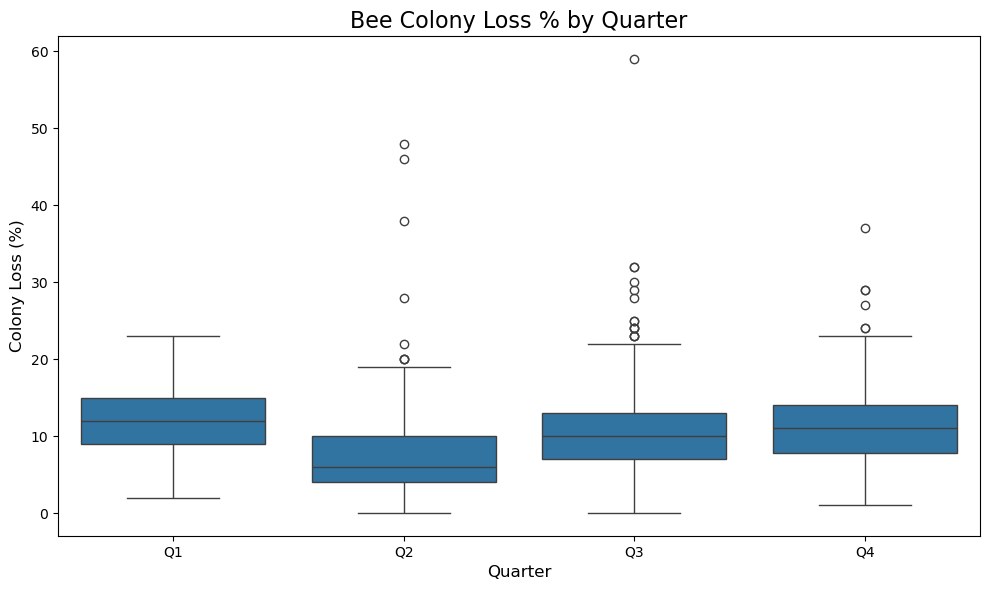

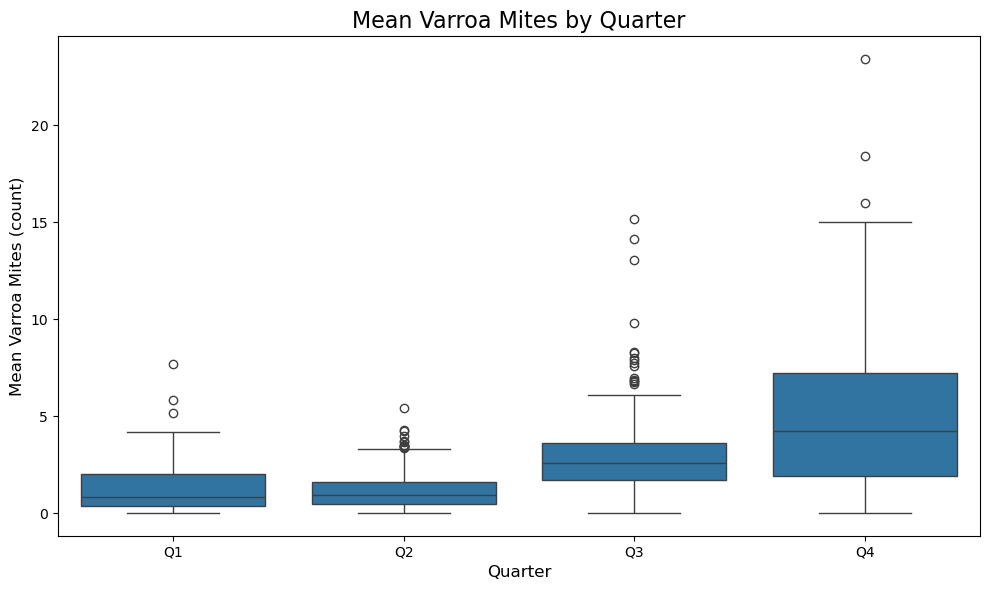

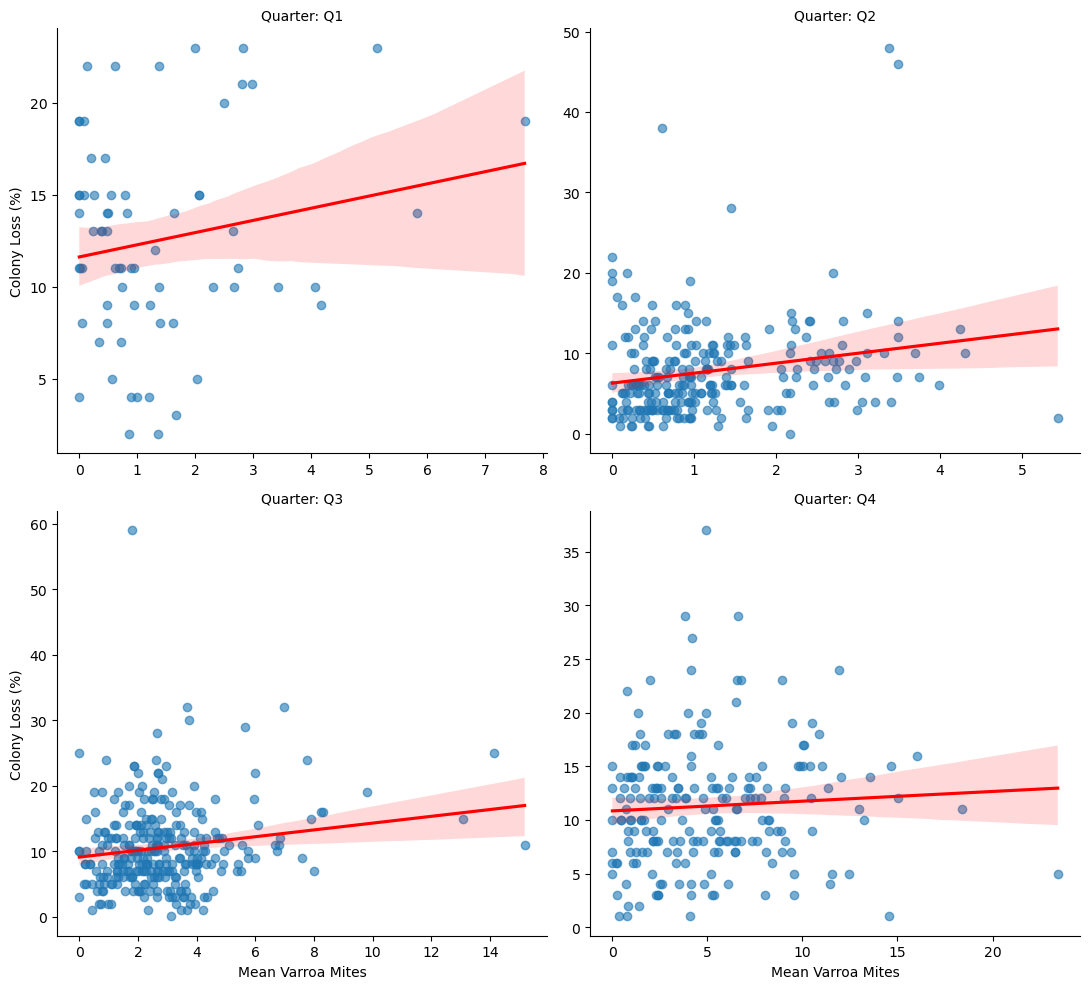

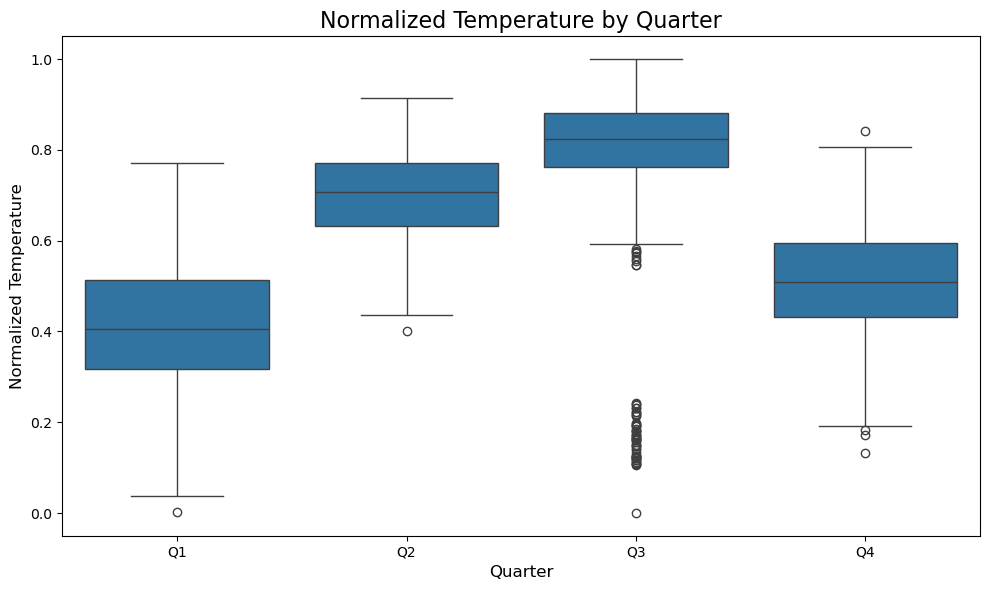

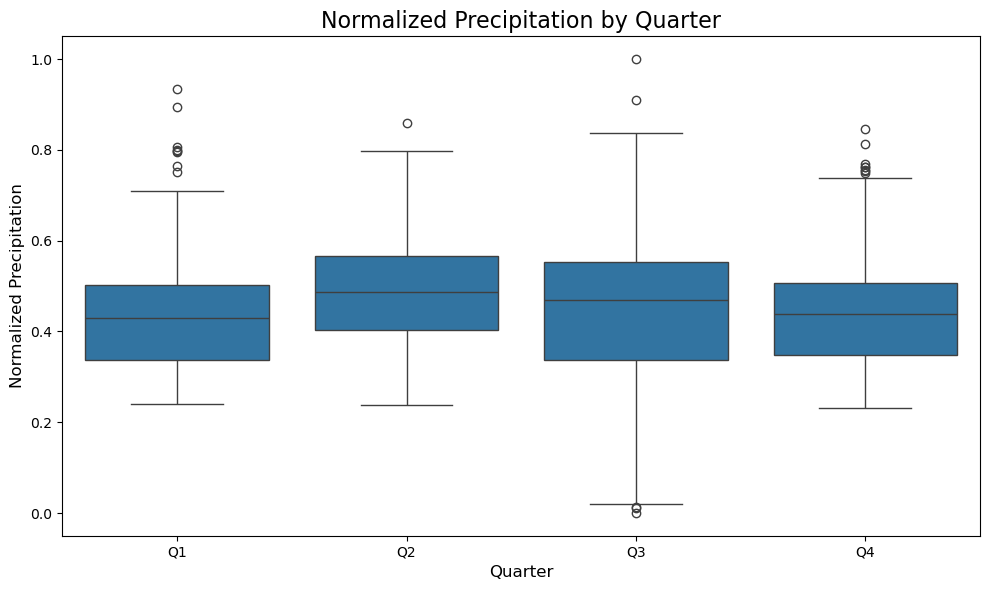

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("Starting quarterly EDA...")

# Resolve repo-relative paths (notebook runs from notebooks/ by default)
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"

# --- Part 1: Analyze Bee Loss and Varroa Mites ---
print("Loading combined bee and varroa data...")

combined_path = INTERIM_DIR / "combined_nass_aphis_weather_1028_df.csv"

try:
    combined_df = pd.read_csv(combined_path)
    print(f"Loaded: {combined_path}")
except FileNotFoundError:
    print(f"Error: '{combined_path}' not found. Check that the file exists in data/interim.")
    raise
except Exception as e:
    print(f"An error occurred loading the file: {e}")
    raise

# Helper to find a column by alternatives
def pick_col(cols, *candidates):
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

# Normalize column names but keep original casing references
cols = list(combined_df.columns)
y_col = pick_col(cols, 'sample_year', 'year', 'Year')
q_col = pick_col(cols, 'quarter', 'Quarter', 'qtr')
s_col = pick_col(cols, 'state_code', 'state', 'State')
v_col = pick_col(cols, 'mean_varroa', 'Mean_Varroa', 'varroa_mean')
# Common variants for loss percent
l_col = pick_col(
    cols,
    'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES',
    'Loss_Pct', 'loss_pct', 'percent_loss', 'loss_rate', 'loss_percent',
    'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES (%)'
)

missing = [name for name, col in [
    ('year', y_col), ('quarter', q_col), ('state', s_col), ('mean_varroa', v_col), ('loss_pct', l_col)
] if col is None]
if missing:
    print("Columns available:", list(combined_df.columns))
    raise KeyError(f"Required columns not found or ambiguous: {missing}")

# Build working DataFrame with consistent names
bee_varroa_df = combined_df[[y_col, q_col, s_col, v_col, l_col]].copy()
bee_varroa_df.rename(columns={
    y_col: 'Year',
    q_col: 'Quarter',
    s_col: 'State',
    v_col: 'Mean_Varroa',
    l_col: 'Loss_Pct',
}, inplace=True)

# Coerce numerics
bee_varroa_df['Mean_Varroa'] = pd.to_numeric(bee_varroa_df['Mean_Varroa'], errors='coerce')
bee_varroa_df['Loss_Pct'] = pd.to_numeric(bee_varroa_df['Loss_Pct'], errors='coerce')

# Normalize Quarter to Q1..Q4
q = bee_varroa_df['Quarter']
if pd.api.types.is_numeric_dtype(q):
    bee_varroa_df['Quarter'] = q.astype('Int64').map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
else:
    # strip and title
    q_norm = q.astype(str).str.strip().str.upper()
    # Handle forms like 1,2,3,4 as strings and 'Q1' etc.
    q_norm = q_norm.replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    # Ensure startswith 'Q'
    bee_varroa_df['Quarter'] = np.where(q_norm.str.match(r'^Q[1-4]$'), q_norm, np.nan)

# Drop rows where our key metrics are missing
bee_varroa_df.dropna(subset=['Mean_Varroa', 'Loss_Pct', 'Quarter'], inplace=True)

# Ensure Quarter order is correct for plotting
quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
bee_varroa_df['Quarter'] = pd.Categorical(bee_varroa_df['Quarter'], categories=quarter_order, ordered=True)

print("Data loaded and cleaned. Generating plots...")

# Plot 1: Bee Loss by Quarter
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quarter', y='Loss_Pct', data=bee_varroa_df)
plt.title('Bee Colony Loss % by Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Colony Loss (%)', fontsize=12)
plt.tight_layout()
print("Rendered loss_by_quarter figure")

# Plot 2: Mean Varroa by Quarter
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quarter', y='Mean_Varroa', data=bee_varroa_df)
plt.title('Mean Varroa Mites by Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Mean Varroa Mites (count)', fontsize=12)
plt.tight_layout()
print("Rendered varroa_by_quarter figure")

# Plot 3: Varroa vs. Bee Loss — 2×2 grid by quarter (no savefig)
print("Generating 2×2 grid of Varroa vs. Loss by quarter...")
g = sns.lmplot(
    x='Mean_Varroa', y='Loss_Pct',
    col='Quarter', col_order=quarter_order, col_wrap=2,
    data=bee_varroa_df,
    height=5, aspect=1.1,
    scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'},
    facet_kws={'sharex': False, 'sharey': False, 'despine': True}
)
g.set_axis_labels('Mean Varroa Mites', 'Colony Loss (%)')
g.set_titles(col_template='Quarter: {col_name}')
plt.tight_layout()
print("Rendered 2×2 grid for varroa vs loss")

# --- Part 2: Analyze Weather Data Separately ---
print("\nLoading normalized weather data...")
weather_path = DATA_DIR / 'normalized_weather_data.csv'
try:
    weather_df = pd.read_csv(weather_path)
    print(f"Loaded: {weather_path}")
except FileNotFoundError:
    print(f"Error: '{weather_path}' not found. Skipping weather analysis.")
    weather_df = None  # Continue without weather if not found
except Exception as e:
    print(f"An error occurred loading weather data: {e}")
    weather_df = None

if weather_df is not None:
    # Normalize column names for expected usage
    if 'Quarter' not in weather_df.columns and 'quarter' in weather_df.columns:
        weather_df.rename(columns={'quarter':'Quarter'}, inplace=True)
    # Ensure Quarter order is correct
    weather_df['Quarter'] = weather_df['Quarter'].astype(str).str.strip().str.upper().replace({'1':'Q1','2':'Q2','3':'Q3','4':'Q4'})
    weather_df['Quarter'] = pd.Categorical(weather_df['Quarter'], categories=quarter_order, ordered=True)

    # Plot 4: Normalized Temperature by Quarter (tmpc)
    if {'Quarter','tmpc'}.issubset(weather_df.columns):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Quarter', y='tmpc', data=weather_df)
        plt.title('Normalized Temperature by Quarter', fontsize=16)
        plt.xlabel('Quarter', fontsize=12)
        plt.ylabel('Normalized Temperature', fontsize=12)
        plt.tight_layout()
        print("Rendered temp_by_quarter figure")
    else:
        print("Skipping temperature plot: columns 'Quarter' and 'tmpc' not both found.")

    # Plot 5: Normalized Precipitation by Quarter (pcpn)
    if {'Quarter','pcpn'}.issubset(weather_df.columns):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Quarter', y='pcpn', data=weather_df)
        plt.title('Normalized Precipitation by Quarter', fontsize=16)
        plt.xlabel('Quarter', fontsize=12)
        plt.ylabel('Normalized Precipitation', fontsize=12)
        plt.tight_layout()
        print("Rendered precip_by_quarter figure")
    else:
        print("Skipping precipitation plot: columns 'Quarter' and 'pcpn' not both found.")

print("\nEDA complete.")